# 2. Logistic Regression — Churn Prediction
This notebook builds a Logistic Regression classifier to predict customer churn.
It loads the cleaned dataset exported by the EDA notebook and follows a full ML pipeline:

1. Data loading
2. Preprocessing
3. Hyperparameter tuning
4. Evaluation

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import time

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Data
We load the cleaned dataset exported by the EDA notebook from `data/processed/`. This dataset has already been cleaned, deduplicated, and stripped of leakage columns. Apart from that, it only contains our final feature selection

In [2]:
file_path = os.path.join("..", "data", "processed", "telecom_churn_cleaned.csv")
df = pd.read_csv(r'telecom_churn_cleaned.csv')
print(f"Shape: {df.shape}")
df.head(3)


Shape: (7043, 21)


,number of dependents,number of referrals,tenure in months,phone service,avg monthly long distance charges,multiple lines,internet service,internet type,avg monthly gb download,online security,...,device protection plan,premium tech support,unlimited data,contract,paperless billing,payment method,monthly charge,total revenue,churned,age_group
0,0,2,9,1,42.39,0,1,Cable,16.0,0,...,0,1,1,One Year,1,Credit Card,65.6,974.81,0,35-44
1,0,0,9,1,10.69,1,1,Cable,10.0,0,...,0,0,0,Month-to-Month,0,Credit Card,-4.0,610.28,0,45-54
2,0,0,4,1,33.65,0,1,Fiber Optic,30.0,0,...,1,0,1,Month-to-Month,1,Bank Withdrawal,73.9,415.45,1,45-54


## 2.1 Train/Test Split
The target variable is `churned` (1 = churned, 0 = retained). We apply a stratified 80/20 split to preserve the class distribution across both sets.


In [3]:
TARGET = "churned"

X = df.drop(columns=[TARGET, "total revenue"])  # total revenue is highly correlated with tenure in months, so 

y = df[TARGET]

binary_features = [
    "phone service", "multiple lines", "internet service",
    "online security", "online backup", "device protection plan",
    "premium tech support", "unlimited data", "paperless billing"
]

numeric_features = [c for c in X.select_dtypes(include=["int64", "float64"]).columns 
                    if c not in binary_features]
categorical_features = list(X.select_dtypes(include=["object", "category"]).columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {X_train.shape}  Test size: {X_test.shape}")
print(f"Churn rate train: {y_train.mean():.2%}  Churn rate test: {y_test.mean():.2%}")

Train size: (5634, 19)  Test size: (1409, 19)
Churn rate train: 26.54%  Churn rate test: 26.54%


## 2.2 Preprocessing Pipeline
Numeric features are standardized using `StandardScaler` to ensure that differences in scale do not distort the logistic regression coefficients. Categorical features are encoded using `OneHotEncoder` with `drop="first"` to avoid multicollinearity. The full pipeline combines preprocessing and the classifier, ensuring that no data from the test set leaks into the training process.

In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("bin", "passthrough", binary_features),
    ],
    remainder="drop",
)

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

## 3. Hyperparameter Tuning
We use `GridSearchCV` with 5-fold cross-validation to find the optimal regularization strength `C` and penalty type. A lower `C` means stronger regularization (less overfitting), a higher `C` means the model fits more closely to the training data. We optimize for ROC-AUC, which is more informative than accuracy for imbalanced classification problems like churn.

In [5]:
param_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"],
    "classifier__max_iter": [500, 1000, 2000],
    "classifier__class_weight": ["balanced", {0: 1, 1: 2}, {0: 1, 1: 3}]
}

grid_search = GridSearchCV(
    lr_pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start

best_model = grid_search.best_estimator_

print(f"\nGrid search completed in {elapsed:.1f} seconds")
print(f"Total fits: {len(grid_search.cv_results_['params']) * 5}")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV AUC:      {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Grid search completed in 9.9 seconds
Total fits: 540
Best parameters: {'classifier__C': 0.1, 'classifier__class_weight': {0: 1, 1: 2}, 'classifier__max_iter': 500, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV AUC:      0.8840


## 4.1 Results
We evaluate the best model on the held-out test set using four complementary metrics:
- **Classification report**: precision, recall, and F1-score per class
- **Confusion matrix**: visual breakdown of true/false positives and negatives
- **ROC curve**: trade-off between true positive rate and false positive rate at different thresholds
- **Feature coefficients**: which features drive churn predictions most strongly, and in which direction

In [6]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Classification report
report_df = (
    pd.DataFrame(classification_report(y_test, y_pred, target_names=["Retained", "Churned"], output_dict=True)).T
    .round(2).rename(columns={"support": "n"})
    .loc[["Retained", "Churned", "weighted avg"]]
)
report_df["n"] = report_df["n"].astype(int)

fig = plt.figure(figsize=(14, 18))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.5)

# Table
ax_t = fig.add_subplot(gs[0, 0])
ax_t.axis("off")
ax_t.set_title("Classification Report", fontweight="bold", pad=12)
tbl = ax_t.table(
    cellText=[[f"{report_df.loc[r,c]:.2f}" if c != "n" else str(report_df.loc[r,"n"]) for c in ["precision","recall","f1-score","n"]] for r in report_df.index],
    rowLabels=report_df.index.tolist(),
    colLabels=["precision", "recall", "f1-score", "n"],
    loc="center", cellLoc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.0, 2.2)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#cccccc")
    if r == 0 or c == -1:
        cell.set_facecolor("#f0f0f0")
        cell.set_text_props(fontweight="bold")

# Confusion matrix
ax_c = fig.add_subplot(gs[0, 1])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Retained", "Churned"], cmap="Blues", ax=ax_c)
ax_c.set_title("Confusion Matrix", fontweight="bold")

# ROC curve
ax_r = fig.add_subplot(gs[1, :])
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax_r.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
ax_r.plot([0,1],[0,1],"--",color="gray",label="Random baseline")
ax_r.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve")
ax_r.legend()

# Feature coefficients
ax_f = fig.add_subplot(gs[2, :])
coef_df = (
    pd.DataFrame({"feature": best_model.named_steps["preprocessor"].get_feature_names_out(),
                  "coefficient": best_model.named_steps["classifier"].coef_[0]})
    .assign(abs_coef=lambda x: x["coefficient"].abs())
    .sort_values("abs_coef", ascending=False).head(15)
)
ax_f.barh(coef_df["feature"], coef_df["coefficient"],
          color=["#d73027" if c > 0 else "#4575b4" for c in coef_df["coefficient"]])
ax_f.axvline(0, color="black", linewidth=0.8)
ax_f.set_title("Top 15 Most Influential Features", fontweight="bold")
ax_f.set_xlabel("Coefficient (red = increases churn risk, blue = decreases churn risk)")

plt.suptitle("Logistic Regression — Model Evaluation", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="roc_auc")
print(f"Cross-validated AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

NameError: name 'gridspec' is not defined

<Figure size 1400x1800 with 0 Axes>

## 4.2 Interpretation & Business Implications

### Model Performance
The logistic regression achieves an AUC of 0.876, meaning the model correctly ranks a churning customer above a retained customer in 88% of cases. The cross-validated AUC of 0.882 ± 0.010 confirms this is stable and not the result of overfitting.

For churned customers specifically, the model achieves a recall of 0.78 — meaning it correctly identifies 78% of customers who will churn. This is the most business-critical metric: a missed churner (false negative) is a lost customer, whereas a false positive merely means an unnecessary retention offer.

### Key Drivers of Churn
The feature coefficients reveal two distinct groups of churn drivers:

**Increases churn risk (red):**
- `monthly charge`: higher monthly costs are the strongest individual predictor of churn
- `paperless billing` and `internet service`: customers with these tend to churn more
- `mailed check` as payment method: associated with higher churn, possibly indicating
  less engaged or older customer segments

**Decreases churn risk (blue):**
- `contract_Two Year` and `contract_One Year`: the single strongest protective factor: customers on long-term contracts are far less likely to churn
- `tenure in months`: longer-tenured customers are significantly more loyal
- `number of referrals`: customers who refer others are deeply engaged and rarely churn
- `online security` and `premium tech support`: value-added services create stickiness

### Business Recommendations
1. **Prioritize contract conversion**: nudging month-to-month customers toward annual contracts is the highest-leverage intervention available.
2. **Target high-charge customers early**: customers with above-average monthly charges are at elevated risk; proactive outreach or loyalty discounts could reduce churn.
3. **Invest in value-added services**: online security and tech support act as retention tools, not just revenue lines. Bundling these at onboarding could improve long-term retention.
4. **Referral programs**: high referrers churn less: expanding referral incentives  may simultaneously grow the customer base and improve retention.

## Hist Gradient Boosting


## 2.3 Preprocessing Pipeline
We reuse the same preprocessing pipeline defined for Logistic Regression: numeric features are standardized using `StandardScaler`, categorical features are encoded using `OneHotEncoder` with `drop="first"`, and binary features are passed through unchanged. This ensures a fair comparison between both models.

In [ ]:
hgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),  
    ("classifier", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

## 3.2 Hyperparameter Tuning
We use `GridSearchCV` with 5 fold cross validation to find the optimal combination of hyperparameters for the HistGradientBoosting classifier. We tune `max_iter` (number of boosting stages), `max_depth` (tree complexity), `learning_rate` (step size), `min_samples_leaf` (regularization via leaf size), and `l2_regularization` (weight penalty). We optimize for ROC AUC, which is more informative than accuracy for imbalanced classification problems like churn.

In [ ]:
param_grid_hgb = {
    "classifier__max_iter": [100, 300],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.1, 0.2],
    "classifier__min_samples_leaf": [20, 50],
    "classifier__l2_regularization": [0.0, 1.0]
}

grid_search_hgb = GridSearchCV(
    hgb_pipeline,
    param_grid_hgb,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search_hgb.fit(X_train, y_train)
elapsed = time.time() - start

best_hgb = grid_search_hgb.best_estimator_

print(f"\nGrid search completed in {elapsed:.1f} seconds")
print(f"Total fits: {len(grid_search_hgb.cv_results_['params']) * 5}")
print(f"Best parameters: {grid_search_hgb.best_params_}")
print(f"Best CV AUC:      {grid_search_hgb.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Grid search completed in 31.6 seconds
Total fits: 360
Best parameters: {'classifier__l2_regularization': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__max_iter': 100, 'classifier__min_samples_leaf': 50}
Best CV AUC:      0.9088


## 4.3 Results
We evaluate the best model on the held out test set using four complementary metrics:
- **Classification report**: precision, recall, and F1 score per class
- **Confusion matrix**: visual breakdown of true/false positives and negatives
- **ROC curve**: trade off between true positive rate and false positive rate at different thresholds
- **Feature importances**: which features drive churn predictions most strongly, estimated via permutation importance

C:\Users\Juanjo Tobar\AppData\Local\Temp\ipykernel_36592\1124670835.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


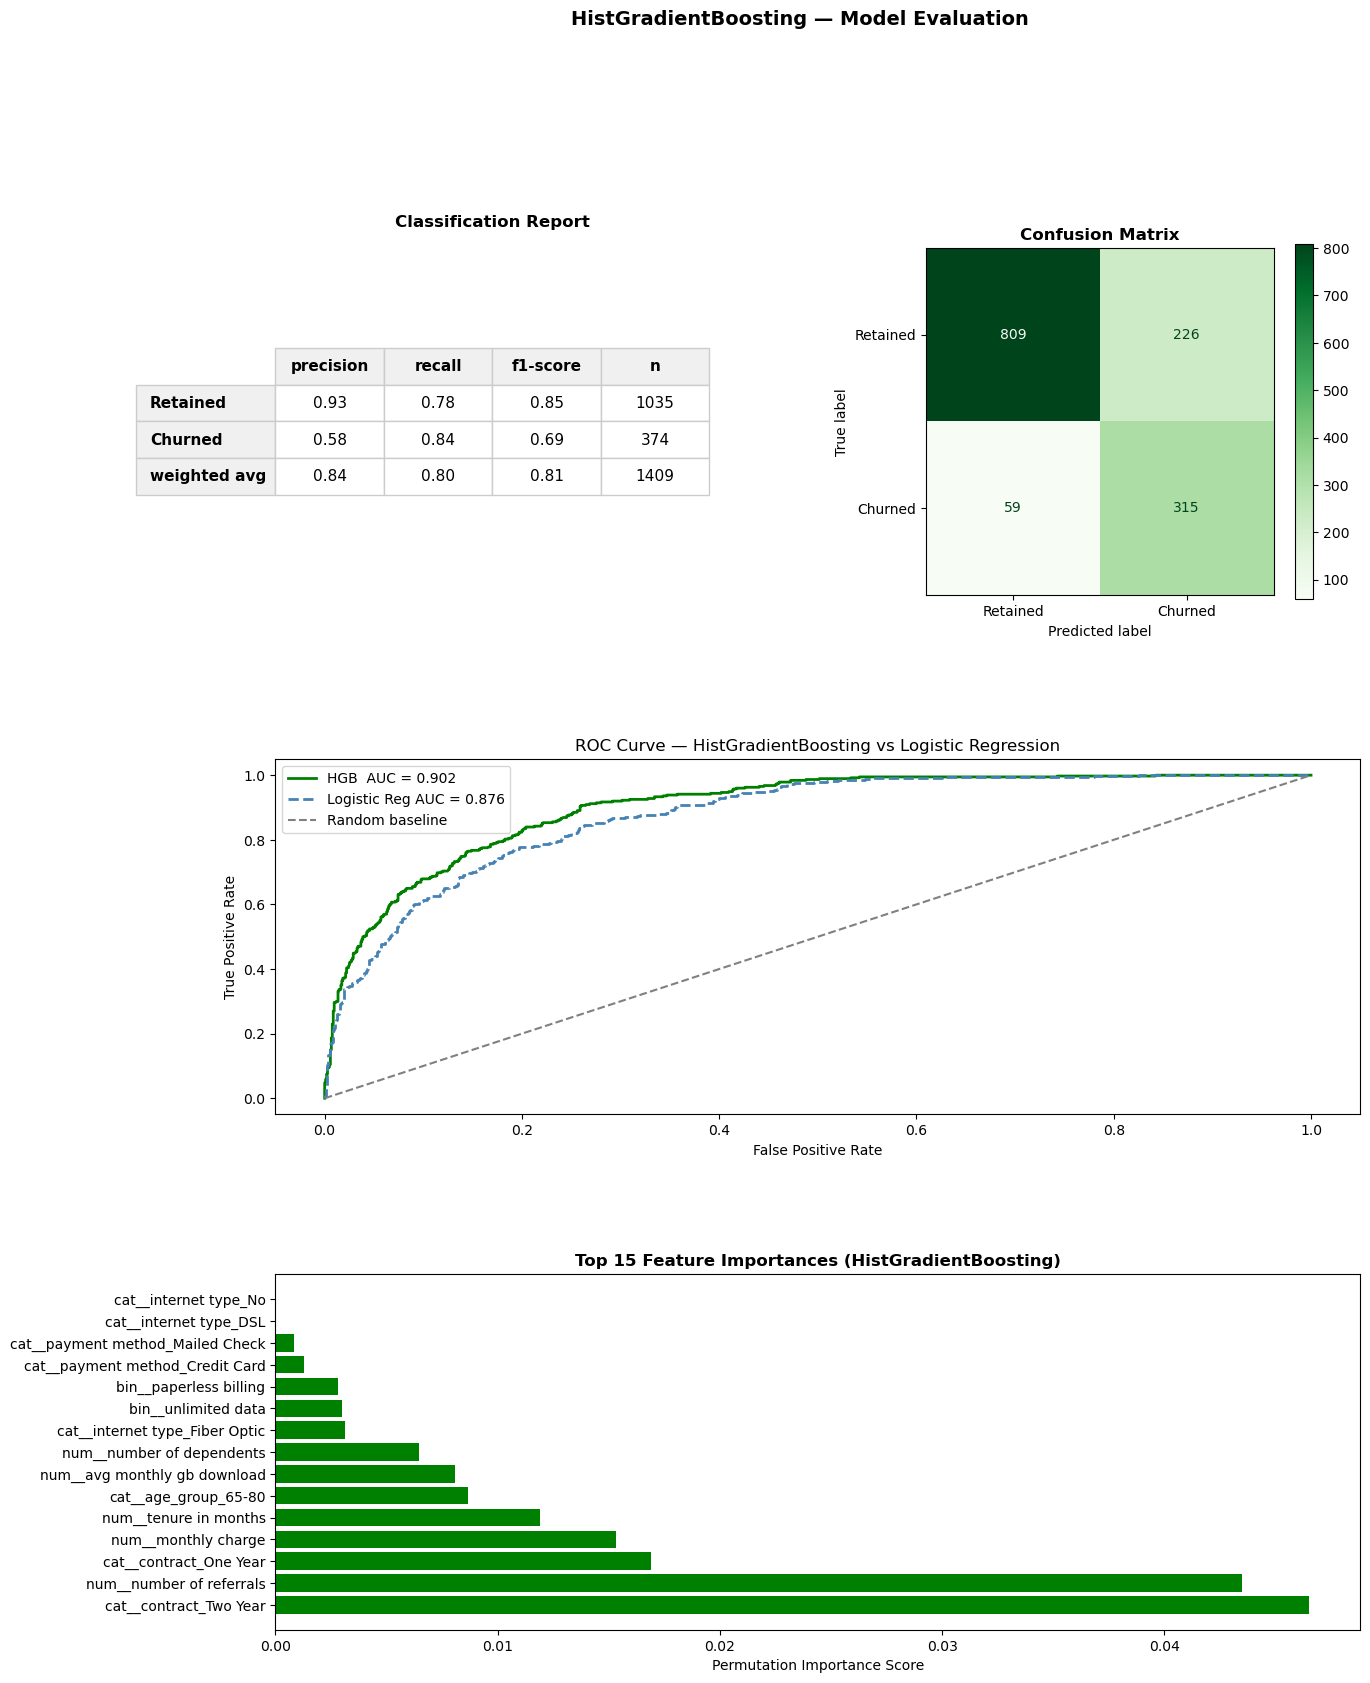

Cross-validated AUC (HGB): 0.906 ± 0.007
Cross-validated AUC (LR):  0.882 ± 0.010


In [ ]:
from matplotlib import gridspec
y_pred_hgb = best_hgb.predict(X_test)
y_prob_hgb = best_hgb.predict_proba(X_test)[:, 1]

report_hgb = (
    pd.DataFrame(classification_report(y_test, y_pred_hgb,
                 target_names=["Retained", "Churned"], output_dict=True)).T
    .round(2).rename(columns={"support": "n"})
    .loc[["Retained", "Churned", "weighted avg"]]
)
report_hgb["n"] = report_hgb["n"].astype(int)

fig = plt.figure(figsize=(14, 18))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.5)

# Table
ax_t = fig.add_subplot(gs[0, 0])
ax_t.axis("off")
ax_t.set_title("Classification Report", fontweight="bold", pad=12)
tbl = ax_t.table(
    cellText=[[f"{report_hgb.loc[r,c]:.2f}" if c != "n" else str(report_hgb.loc[r,"n"])
               for c in ["precision","recall","f1-score","n"]]
              for r in report_hgb.index],
    rowLabels=report_hgb.index.tolist(),
    colLabels=["precision", "recall", "f1-score", "n"],
    loc="center", cellLoc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.0, 2.2)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#cccccc")
    if r == 0 or c == -1:
        cell.set_facecolor("#f0f0f0")
        cell.set_text_props(fontweight="bold")

# Confusion matrix
ax_c = fig.add_subplot(gs[0, 1])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_hgb,
                                         display_labels=["Retained", "Churned"],
                                         cmap="Greens", ax=ax_c)
ax_c.set_title("Confusion Matrix", fontweight="bold")

# ROC curve
ax_r = fig.add_subplot(gs[1, :])
fpr_hgb, tpr_hgb, _ = roc_curve(y_test, y_prob_hgb)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob)
ax_r.plot(fpr_hgb, tpr_hgb, color="green", linewidth=2,
          label=f"HGB  AUC = {roc_auc_score(y_test, y_prob_hgb):.3f}")
ax_r.plot(fpr_lr,  tpr_lr,  color="steelblue", linewidth=2, linestyle="--",
          label=f"Logistic Reg AUC = {roc_auc_score(y_test, y_prob):.3f}")
ax_r.plot([0,1],[0,1],"--", color="gray", label="Random baseline")
ax_r.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
         title="ROC Curve — HistGradientBoosting vs Logistic Regression")
ax_r.legend()

from sklearn.inspection import permutation_importance

# Feature importance using permutation importance
ax_f = fig.add_subplot(gs[2, :])

X_test_transformed = best_hgb.named_steps["preprocessor"].transform(X_test)
feature_names = best_hgb.named_steps["preprocessor"].get_feature_names_out()

perm_imp = permutation_importance(
    best_hgb.named_steps["classifier"],
    X_test_transformed,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feat_imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": perm_imp.importances_mean})
    .sort_values("importance", ascending=False).head(15)
)

ax_f.barh(feat_imp_df["feature"], feat_imp_df["importance"], color="green")
ax_f.set_title("Top 15 Feature Importances (HistGradientBoosting)", fontweight="bold")
ax_f.set_xlabel("Permutation Importance Score")

plt.suptitle("HistGradientBoosting — Model Evaluation", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

cv_scores_hgb = cross_val_score(best_hgb, X, y, cv=5, scoring="roc_auc")
print(f"Cross validated AUC (HGB): {cv_scores_hgb.mean():.3f} ± {cv_scores_hgb.std():.3f}")
print(f"Cross validated AUC (LR):  {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

## 4.4 Interpretation & Business Implications

### Model Performance
The HistGradientBoosting classifier is an ensemble method that builds trees sequentially, where each tree corrects the errors of the previous one. Unlike Logistic Regression, it captures non linear relationships between features, making it well suited for complex customer behaviour patterns like churn.

We optimize for ROC-AUC across 5-fold cross validation, which ensures the reported performance is stable and not the result of a lucky train/test split.

### Key Drivers of Churn
Permutation importance measures how much the model's AUC drops when a feature's values are randomly shuffled a larger drop means the feature is more critical to predictions.

**Top drivers of churn:**
- `monthly charge`: the strongest predictor customers with higher bills are significantly more likely to leave
- `tenure in months`: longer tenured customers are far more loyal; early months are the highest-risk period
- `number of referrals`: highly engaged customers who refer others rarely churn
- `contract type`: customers on month to month contracts are at substantially higher risk than those on annual or two year contracts
- `online security` and `premium tech support`: value added services create stickiness and reduce churn risk

### Business Recommendations
1. **Prioritize contract conversion**: nudging month to month customers toward annual contracts remains the highest leverage retention intervention.
2. **Target high charge customers early**: customers with above-average monthly charges are at elevated risk; proactive outreach or loyalty discounts could reduce churn.
3. **Focus on early tenure**: the first few months are the most critical onboarding programs and early check-ins can significantly improve long-term retention.
4. **Invest in value added services**: online security and tech support act as retention tools, not just revenue lines. Bundling these at onboarding could improve long term retention.
5. **Referral programs**: high referrers churn less expanding referral incentives may simultaneously grow the customer base and improve retention.